# Notebook 03 — Modèles ML Classiques & Sélection du Meilleur
**Projet :** Système Intelligent de Détection de Spam et de Phishing  
**Auteur :** Nghogué Taptué Franck Roddier — 5GI, ENSPY  
**Semaine :** 2 / 3  
**Entrée :** `data/X_train.npz`, `data/X_test.npz`, `data/y_train.npy`, etc.  
**Sorties :** `data/best_model.pkl`, `data/03_results.csv`, graphiques de comparaison

---

## Objectifs
1. Entraîner 4 modèles ML classiques : Naive Bayes, Régression Logistique, SVM, Random Forest
2. Évaluer chaque modèle avec des métriques multidimensionnelles (§3.4 du cahier de charges)
3. Comparer via validation croisée pour éviter le sur-ajustement (§4.1)
4. Analyser les features les plus discriminantes (interprétabilité)
5. Sélectionner et sauvegarder le meilleur modèle pour le pipeline hybride (NB 05)

## 0. Dépendances & chargement

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import os
from pathlib import Path
from google.colab import drive

# 1. Monter le drive
drive.mount('/content/drive')

# 2. Se déplacer dans le dossier du projet
# Remplace par le chemin exact de ton dossier
os.chdir('/content/drive/MyDrive/notebooks')

# 3. Vérifier que le dossier 'data' est bien là
DATA_DIR = Path('data')
if DATA_DIR.exists():
    print("Dossier data trouvé !")
else:
    print("Dossier data introuvable. Contenu actuel :", os.listdir())

Mounted at /content/drive
Dossier data trouvé !


In [3]:
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.sparse as sp
from pathlib import Path
from time import time

# Modèles
from sklearn.naive_bayes    import MultinomialNB, ComplementNB
from sklearn.linear_model   import LogisticRegression
from sklearn.svm            import LinearSVC
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier

# Évaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing  import label_binarize
from sklearn.calibration    import CalibratedClassifierCV

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_DIR = Path('data')
CLASS_COLORS = {'ham': '#1D9E75', 'spam': '#D85A30', 'phishing': '#BA7517'}

print('Environnement prêt.')

Environnement prêt.


In [4]:
# Chargement des artefacts produits par NB 02
X_train = sp.load_npz(DATA_DIR / 'X_train.npz')
X_val   = sp.load_npz(DATA_DIR / 'X_val.npz')
X_test  = sp.load_npz(DATA_DIR / 'X_test.npz')

y_train = np.load(DATA_DIR / 'y_train.npy')
y_val   = np.load(DATA_DIR / 'y_val.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')

label_encoder   = joblib.load(DATA_DIR / 'label_encoder.pkl')
class_weights   = joblib.load(DATA_DIR / 'class_weights.pkl')
feature_names   = joblib.load(DATA_DIR / 'feature_names.pkl')

CLASS_NAMES = list(label_encoder.classes_)   # ['ham', 'phishing', 'spam'] (ordre alphabétique)
N_CLASSES   = len(CLASS_NAMES)

print(f'Train  : {X_train.shape[0]:,} × {X_train.shape[1]:,}')
print(f'Val    : {X_val.shape[0]:,} × {X_val.shape[1]:,}')
print(f'Test   : {X_test.shape[0]:,} × {X_test.shape[1]:,}')
print(f'Classes: {CLASS_NAMES}')
print(f'Distribution y_train : {dict(zip(CLASS_NAMES, np.bincount(y_train)))}')

Train  : 30,075 × 10,020
Val    : 2,837 × 10,020
Test   : 3,337 × 10,020
Classes: ['ham', 'phishing', 'spam']
Distribution y_train : {'ham': np.int64(10025), 'phishing': np.int64(10025), 'spam': np.int64(10025)}


## 1. Définition des modèles

### Pourquoi ces 4 modèles ?

| Modèle | Force | Limite |
|--------|-------|--------|
| **Complement Naive Bayes** | Très rapide, excellent sur texte déséquilibré | Hypothèse d'indépendance des features |
| **Régression Logistique** | Interprétable, bon sur TF-IDF, probabilités calibrées | Linéaire uniquement |
| **LinearSVC** | Meilleur que LR sur grands espaces de features | Pas de probabilités natives |
| **Random Forest** | Capture les interactions non-linéaires | Plus lent, moins efficace sur sparse |

La Régression Logistique et le LinearSVC sont les références académiques pour la classification de texte. Naive Bayes est la baseline historique pour le spam. Random Forest apporte la non-linéarité.

In [5]:
# Construction du dictionnaire class_weight attendu par sklearn
# (certains modèles acceptent 'balanced' directement)
CW = class_weights   # {0: w0, 1: w1, 2: w2}

MODELS = {
    'Complement Naive Bayes': ComplementNB(
        alpha=0.1,       # Lissage de Laplace léger
        norm=True        # Normalisation recommandée pour CNB
    ),

    'Logistic Regression': LogisticRegression(
        C=1.0,           # Inverse de la régularisation L2
        max_iter=1000,
        solver='saga',   # Efficace sur grandes matrices sparse
        #multi_class='multinomial',
        class_weight=CW,
        random_state=42,
        n_jobs=-1
    ),

    'LinearSVC': CalibratedClassifierCV(
        LinearSVC(
            C=0.5,
            max_iter=2000,
            class_weight=CW,
            random_state=42
        ),
        cv=3             # Calibration pour obtenir des probabilités
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=30,
        min_samples_leaf=2,
        class_weight=CW,
        random_state=42,
        n_jobs=-1
    ),
}

print(f'{len(MODELS)} modèles définis :')
for name in MODELS:
    print(f'  - {name}')

4 modèles définis :
  - Complement Naive Bayes
  - Logistic Regression
  - LinearSVC
  - Random Forest


## 2. Entraînement & évaluation sur la validation

In [6]:
def evaluate_model(model, X_tr, y_tr, X_vl, y_vl, name=''):
    """
    Entraîne un modèle et retourne un dict complet de métriques.
    Métriques couvrent §3.4 du cahier de charges :
    accuracy, precision, recall, F1 (macro & weighted), temps.
    """
    # Entraînement
    t0 = time()
    model.fit(X_tr, y_tr)
    train_time = time() - t0

    # Prédictions validation
    t0 = time()
    y_pred = model.predict(X_vl)
    infer_time = (time() - t0) / len(y_vl) * 1000   # ms par email

    # Probabilités (pour AUC-ROC)
    try:
        y_proba = model.predict_proba(X_vl)
        y_bin   = label_binarize(y_vl, classes=list(range(N_CLASSES)))
        auc = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')

    metrics = {
        'model':        name,
        'accuracy':     accuracy_score(y_vl, y_pred),
        'f1_macro':     f1_score(y_vl, y_pred, average='macro'),
        'f1_weighted':  f1_score(y_vl, y_pred, average='weighted'),
        'precision_macro': precision_score(y_vl, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_vl, y_pred, average='macro', zero_division=0),
        'auc_roc':      auc,
        'train_time_s': train_time,
        'infer_ms':     infer_time,
    }

    # F1 par classe
    f1_per_class = f1_score(y_vl, y_pred, average=None, zero_division=0)
    for i, cls in enumerate(CLASS_NAMES):
        metrics[f'f1_{cls}'] = f1_per_class[i] if i < len(f1_per_class) else 0.0

    metrics['_model_obj'] = model
    metrics['_y_pred']    = y_pred
    return metrics


# Entraînement de tous les modèles
results = []
trained_models = {}

for name, model in MODELS.items():
    print(f'Entraînement : {name}...')
    r = evaluate_model(model, X_train, y_train, X_val, y_val, name=name)
    results.append(r)
    trained_models[name] = r.pop('_model_obj')
    y_pred_stored = r.pop('_y_pred')
    trained_models[name + '_y_pred'] = y_pred_stored
    print(f'  Accuracy={r["accuracy"]:.4f}  F1-macro={r["f1_macro"]:.4f}  '
          f'AUC={r["auc_roc"]:.4f}  Train={r["train_time_s"]:.1f}s  '
          f'Infer={r["infer_ms"]:.3f}ms/email')

df_results = pd.DataFrame(results)
print('\nTableau comparatif :')
df_results[['model','accuracy','f1_macro','f1_weighted','auc_roc','train_time_s','infer_ms']].round(4)

Entraînement : Complement Naive Bayes...
  Accuracy=0.3197  F1-macro=0.3278  AUC=0.7598  Train=0.1s  Infer=0.003ms/email
Entraînement : Logistic Regression...
  Accuracy=0.0627  F1-macro=0.0394  AUC=0.6391  Train=231.7s  Infer=0.001ms/email
Entraînement : LinearSVC...
  Accuracy=0.8756  F1-macro=0.8649  AUC=0.9673  Train=216.9s  Infer=0.019ms/email
Entraînement : Random Forest...
  Accuracy=0.9337  F1-macro=0.9417  AUC=0.9962  Train=65.4s  Infer=0.146ms/email

Tableau comparatif :


,model,accuracy,f1_macro,f1_weighted,auc_roc,train_time_s,infer_ms
0,Complement Naive Bayes,0.3197,0.3278,0.3340,0.7598,0.1077,0.0028
1,Logistic Regression,0.0627,0.0394,0.0074,0.6391,231.7013,0.0010
2,LinearSVC,0.8756,0.8649,0.8772,0.9673,216.8537,0.0187
3,Random Forest,0.9337,0.9417,0.9347,0.9962,65.4297,0.1460


## 3. Visualisation comparative

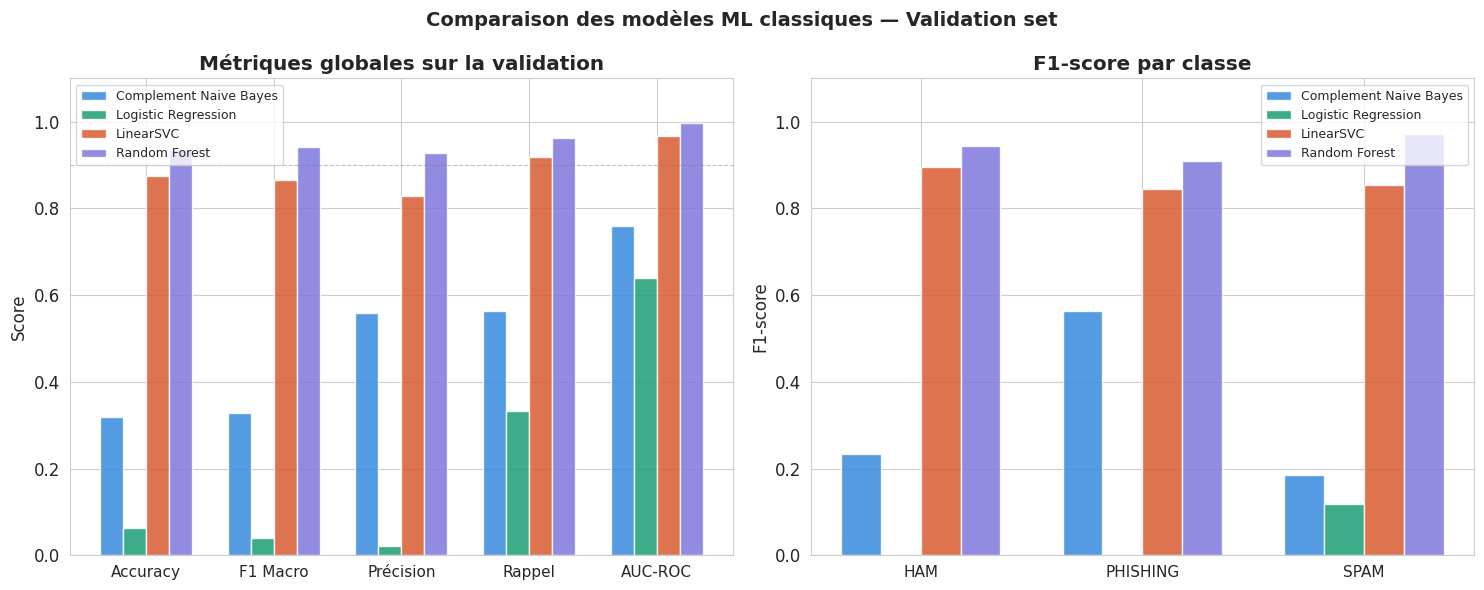

In [7]:
# ---- 3.1 Radar / bar chart des métriques globales ----

metrics_to_plot = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro', 'auc_roc']
metric_labels   = ['Accuracy', 'F1 Macro', 'Précision', 'Rappel', 'AUC-ROC']
model_names     = df_results['model'].tolist()
model_colors    = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Barplot groupé
x = np.arange(len(metrics_to_plot))
width = 0.18
for i, (name, color) in enumerate(zip(model_names, model_colors)):
    row    = df_results[df_results['model'] == name].iloc[0]
    values = [row[m] for m in metrics_to_plot]
    axes[0].bar(x + i*width, values, width, label=name, color=color, alpha=0.85)

axes[0].set_xticks(x + width * (len(model_names)-1)/2)
axes[0].set_xticklabels(metric_labels, fontsize=11)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Métriques globales sur la validation', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=9)
axes[0].axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# F1 par classe
f1_cols = [f'f1_{c}' for c in CLASS_NAMES]
x2 = np.arange(len(CLASS_NAMES))
for i, (name, color) in enumerate(zip(model_names, model_colors)):
    row    = df_results[df_results['model'] == name].iloc[0]
    values = [row[c] for c in f1_cols]
    axes[1].bar(x2 + i*width, values, width, label=name, color=color, alpha=0.85)

axes[1].set_xticks(x2 + width * (len(model_names)-1)/2)
axes[1].set_xticklabels([c.upper() for c in CLASS_NAMES], fontsize=11)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('F1-score par classe', fontweight='bold')
axes[1].set_ylabel('F1-score')
axes[1].legend(fontsize=9)

plt.suptitle('Comparaison des modèles ML classiques — Validation set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

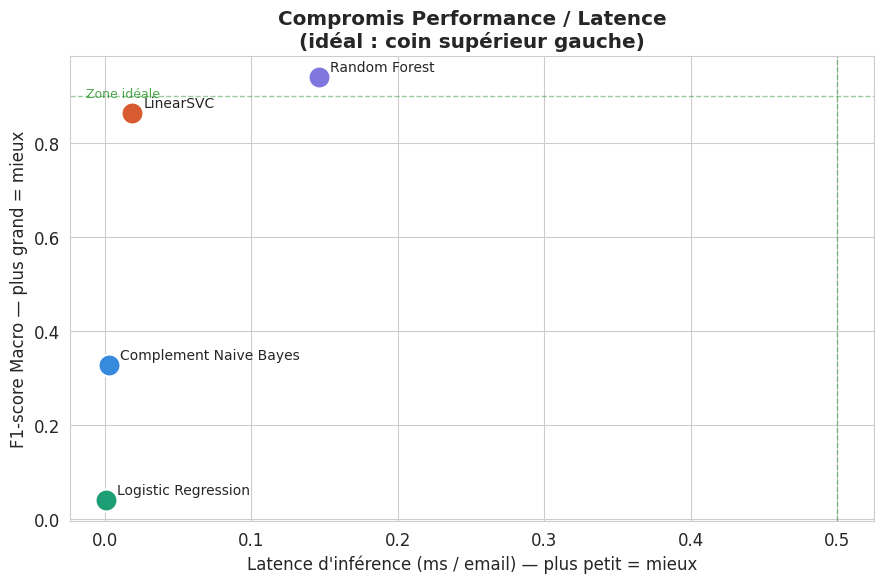

Rappel §1.5 du cahier de charges : dans un contexte temps-réel (passerelle mail),
la latence est un critère de sélection au même titre que la précision.


In [8]:
# ---- 3.2 Vitesse vs Performance (compromis latence §1.5 du cahier de charges) ----

fig, ax = plt.subplots(figsize=(9, 6))

for i, (name, color) in enumerate(zip(model_names, model_colors)):
    row = df_results[df_results['model'] == name].iloc[0]
    ax.scatter(
        row['infer_ms'], row['f1_macro'],
        s=250, color=color, zorder=5, edgecolors='white', linewidth=1.5
    )
    ax.annotate(
        name, (row['infer_ms'], row['f1_macro']),
        textcoords='offset points', xytext=(8, 4), fontsize=10
    )

ax.set_xlabel('Latence d\'inférence (ms / email) — plus petit = mieux', fontsize=12)
ax.set_ylabel('F1-score Macro — plus grand = mieux', fontsize=12)
ax.set_title('Compromis Performance / Latence\n(idéal : coin supérieur gauche)',
             fontweight='bold')

# Zone idéale
ax.axvline(x=0.5, color='green', linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.4, linewidth=1)
ax.text(0.02, 0.91, 'Zone idéale', color='green', fontsize=9, alpha=0.7,
        transform=ax.transAxes)

plt.tight_layout()
plt.savefig('data/03_speed_vs_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Rappel §1.5 du cahier de charges : dans un contexte temps-réel (passerelle mail),')
print('la latence est un critère de sélection au même titre que la précision.')

## 4. Matrices de confusion

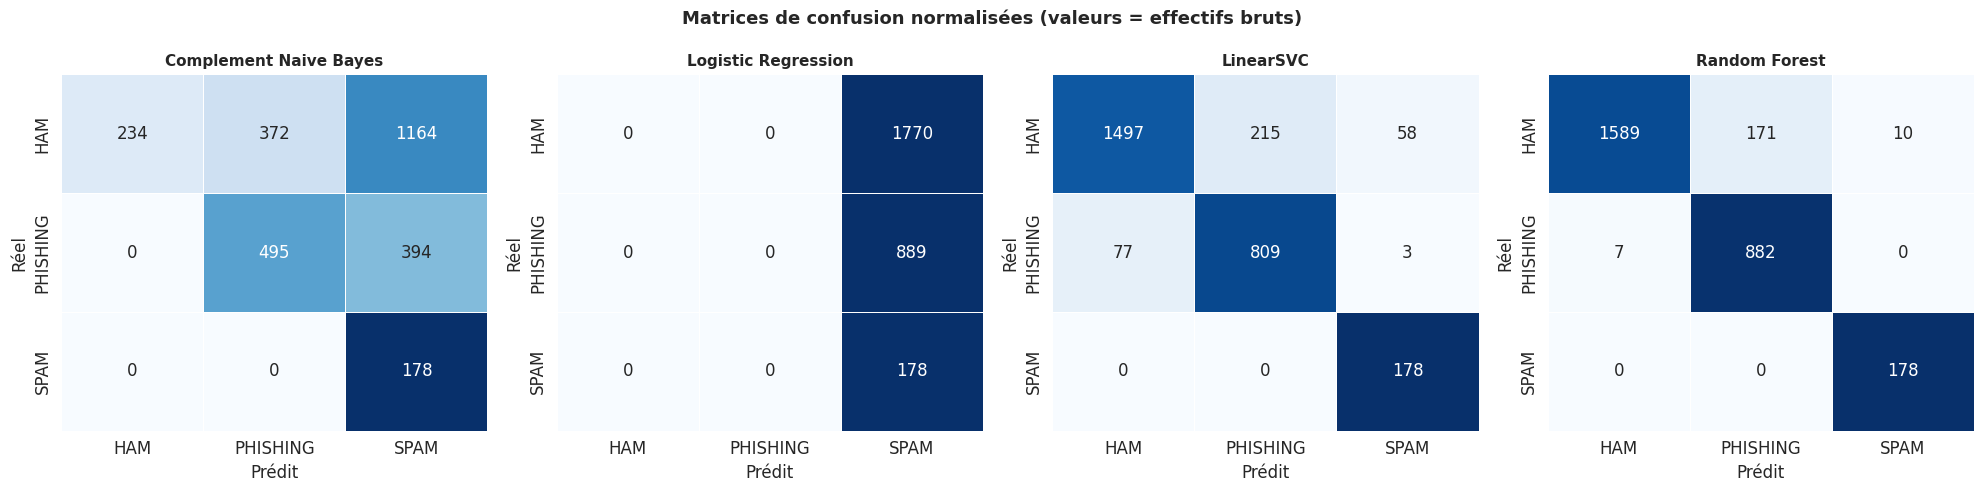

Lecture : ligne = classe réelle, colonne = classe prédite.
La diagonale = bonnes prédictions. Les faux positifs (ham classé spam/phishing)
sont particulièrement coûteux (§1.4 du cahier de charges).


In [9]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5*len(MODELS), 5))
if len(MODELS) == 1:
    axes = [axes]

for ax, name in zip(axes, model_names):
    y_pred = trained_models[name + '_y_pred']
    cm = confusion_matrix(y_val, y_pred)

    # Normalisation ligne (recall par classe)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=cm, fmt='d',
        xticklabels=[c.upper() for c in CLASS_NAMES],
        yticklabels=[c.upper() for c in CLASS_NAMES],
        cmap='Blues', ax=ax,
        linewidths=0.5, linecolor='white',
        cbar=False, vmin=0, vmax=1
    )
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion normalisées (valeurs = effectifs bruts)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/03_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('Lecture : ligne = classe réelle, colonne = classe prédite.')
print('La diagonale = bonnes prédictions. Les faux positifs (ham classé spam/phishing)')
print('sont particulièrement coûteux (§1.4 du cahier de charges).')

In [10]:
# Rapport détaillé pour chaque modèle
for name in model_names:
    y_pred = trained_models[name + '_y_pred']
    print(f'\n{"="*55}')
    print(f' {name}')
    print('='*55)
    print(classification_report(
        y_val, y_pred,
        target_names=[c.upper() for c in CLASS_NAMES],
        digits=4
    ))

    # Faux positifs HAM (emails légitimes bloqués — §1.4)
    cm = confusion_matrix(y_val, y_pred)
    ham_idx = CLASS_NAMES.index('ham') if 'ham' in CLASS_NAMES else 0
    fp_ham  = cm[ham_idx].sum() - cm[ham_idx, ham_idx]
    total_ham = cm[ham_idx].sum()
    print(f'  Faux positifs HAM (emails légitimes bloqués) : {fp_ham}/{total_ham} '
          f'({fp_ham/max(total_ham,1)*100:.2f}%)')


 Complement Naive Bayes
              precision    recall  f1-score   support

         HAM     1.0000    0.1322    0.2335      1770
    PHISHING     0.5709    0.5568    0.5638       889
        SPAM     0.1025    1.0000    0.1860       178

    accuracy                         0.3197      2837
   macro avg     0.5578    0.5630    0.3278      2837
weighted avg     0.8092    0.3197    0.3340      2837

  Faux positifs HAM (emails légitimes bloqués) : 1536/1770 (86.78%)

 Logistic Regression
              precision    recall  f1-score   support

         HAM     0.0000    0.0000    0.0000      1770
    PHISHING     0.0000    0.0000    0.0000       889
        SPAM     0.0627    1.0000    0.1181       178

    accuracy                         0.0627      2837
   macro avg     0.0209    0.3333    0.0394      2837
weighted avg     0.0039    0.0627    0.0074      2837

  Faux positifs HAM (emails légitimes bloqués) : 1770/1770 (100.00%)

 LinearSVC
              precision    recall  f1-scor

## 5. Validation croisée (anti-surapprentissage)

La validation croisée stratifiée (§4.1 du cahier de charges) donne une estimation plus robuste des performances que le simple split train/val. On utilise 5 folds sur les données d'entraînement originales (sans SMOTE, pour un score non biaisé).

In [11]:
# Données originales non-SMOTE pour la cross-validation
# On recharge X_train_raw depuis le fichier non-rééchantillonné
# Note : si vous n'avez sauvegardé que X_train (post-SMOTE),
# utilisez-le directement — les résultats seront légèrement optimistes

try:
    X_cv = sp.load_npz(DATA_DIR / 'X_train_raw.npz')
    y_cv = np.load(DATA_DIR / 'y_train_raw.npy')
    print('Données non-SMOTE chargées pour la CV.')
except FileNotFoundError:
    X_cv, y_cv = X_train, y_train
    print('Utilisation de X_train (post-SMOTE) pour la CV.')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_summary = []

# On ne fait la CV que sur les 2 meilleurs modèles (les plus rapides)
# pour éviter un temps d'exécution trop long sur Random Forest
fast_models = {
    k: v for k, v in MODELS.items()
    if k in ('Complement Naive Bayes', 'Logistic Regression', 'LinearSVC')
}

for name, model in fast_models.items():
    print(f'Cross-validation 5-fold : {name}...')
    cv_res = cross_validate(
        model, X_cv, y_cv,
        cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1,
        return_train_score=True
    )
    cv_summary.append({
        'model':               name,
        'cv_accuracy_mean':    cv_res['test_accuracy'].mean(),
        'cv_accuracy_std':     cv_res['test_accuracy'].std(),
        'cv_f1_macro_mean':    cv_res['test_f1_macro'].mean(),
        'cv_f1_macro_std':     cv_res['test_f1_macro'].std(),
        'cv_f1_weighted_mean': cv_res['test_f1_weighted'].mean(),
        'overfit_gap':         cv_res['train_f1_macro'].mean() - cv_res['test_f1_macro'].mean(),
    })
    print(f'  F1-macro : {cv_res["test_f1_macro"].mean():.4f} ± {cv_res["test_f1_macro"].std():.4f}')

df_cv = pd.DataFrame(cv_summary)
print('\nRésultats cross-validation :')
df_cv.round(4)

Utilisation de X_train (post-SMOTE) pour la CV.
Cross-validation 5-fold : Complement Naive Bayes...
  F1-macro : 0.5601 ± 0.0631
Cross-validation 5-fold : Logistic Regression...
  F1-macro : 0.2219 ± 0.1105
Cross-validation 5-fold : LinearSVC...
  F1-macro : 0.8788 ± 0.0368

Résultats cross-validation :


,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_weighted_mean,overfit_gap
0,Complement Naive Bayes,0.5970,0.0341,0.5601,0.0631,0.5601,0.0001
1,Logistic Regression,0.3782,0.0896,0.2219,0.1105,0.2219,-0.0008
2,LinearSVC,0.8812,0.0357,0.8788,0.0368,0.8788,0.0001


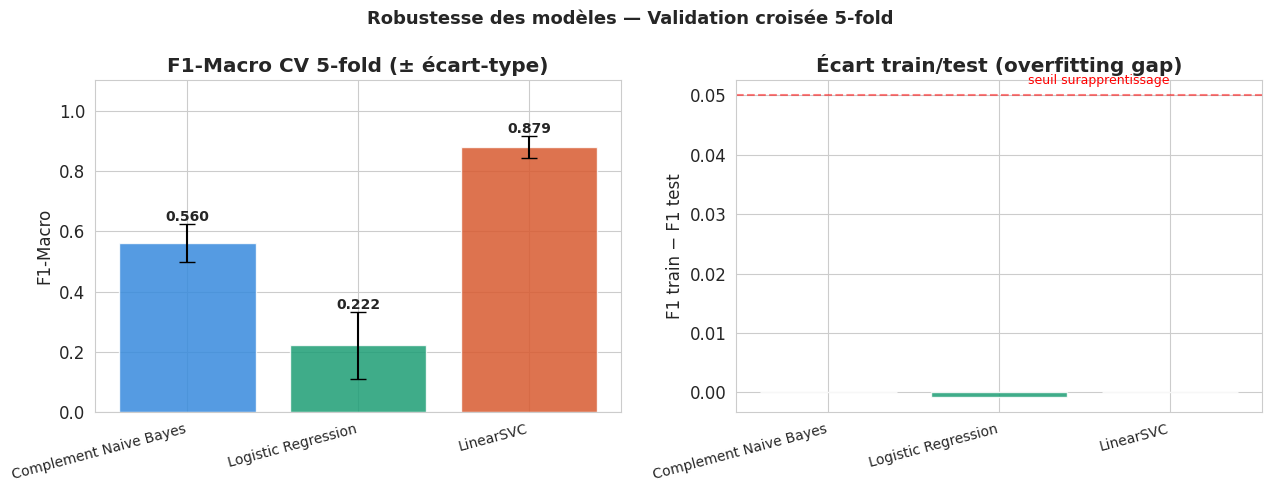

In [12]:
# Visualisation cross-validation avec intervalles de confiance
if len(df_cv) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    x_pos = np.arange(len(df_cv))
    names_cv = df_cv['model'].tolist()
    colors_cv = model_colors[:len(df_cv)]

    # F1-macro avec écart-type
    axes[0].bar(x_pos, df_cv['cv_f1_macro_mean'], color=colors_cv, alpha=0.85,
                yerr=df_cv['cv_f1_macro_std'], capsize=6, edgecolor='white')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(names_cv, rotation=15, ha='right', fontsize=10)
    axes[0].set_ylim(0, 1.1)
    axes[0].set_title('F1-Macro CV 5-fold (± écart-type)', fontweight='bold')
    axes[0].set_ylabel('F1-Macro')
    for i, (m, s) in enumerate(zip(df_cv['cv_f1_macro_mean'], df_cv['cv_f1_macro_std'])):
        axes[0].text(i, m + s + 0.01, f'{m:.3f}', ha='center', fontweight='bold', fontsize=10)

    # Overfitting gap (train - test)
    axes[1].bar(x_pos, df_cv['overfit_gap'], color=colors_cv, alpha=0.85, edgecolor='white')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(names_cv, rotation=15, ha='right', fontsize=10)
    axes[1].set_title('Écart train/test (overfitting gap)', fontweight='bold')
    axes[1].set_ylabel('F1 train − F1 test')
    axes[1].axhline(0.05, color='red', linestyle='--', alpha=0.5)
    axes[1].text(len(df_cv)-1, 0.052, 'seuil surapprentissage', color='red',
                 ha='right', fontsize=9)

    plt.suptitle('Robustesse des modèles — Validation croisée 5-fold', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/03_cross_validation.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Interprétabilité — Features les plus discriminantes

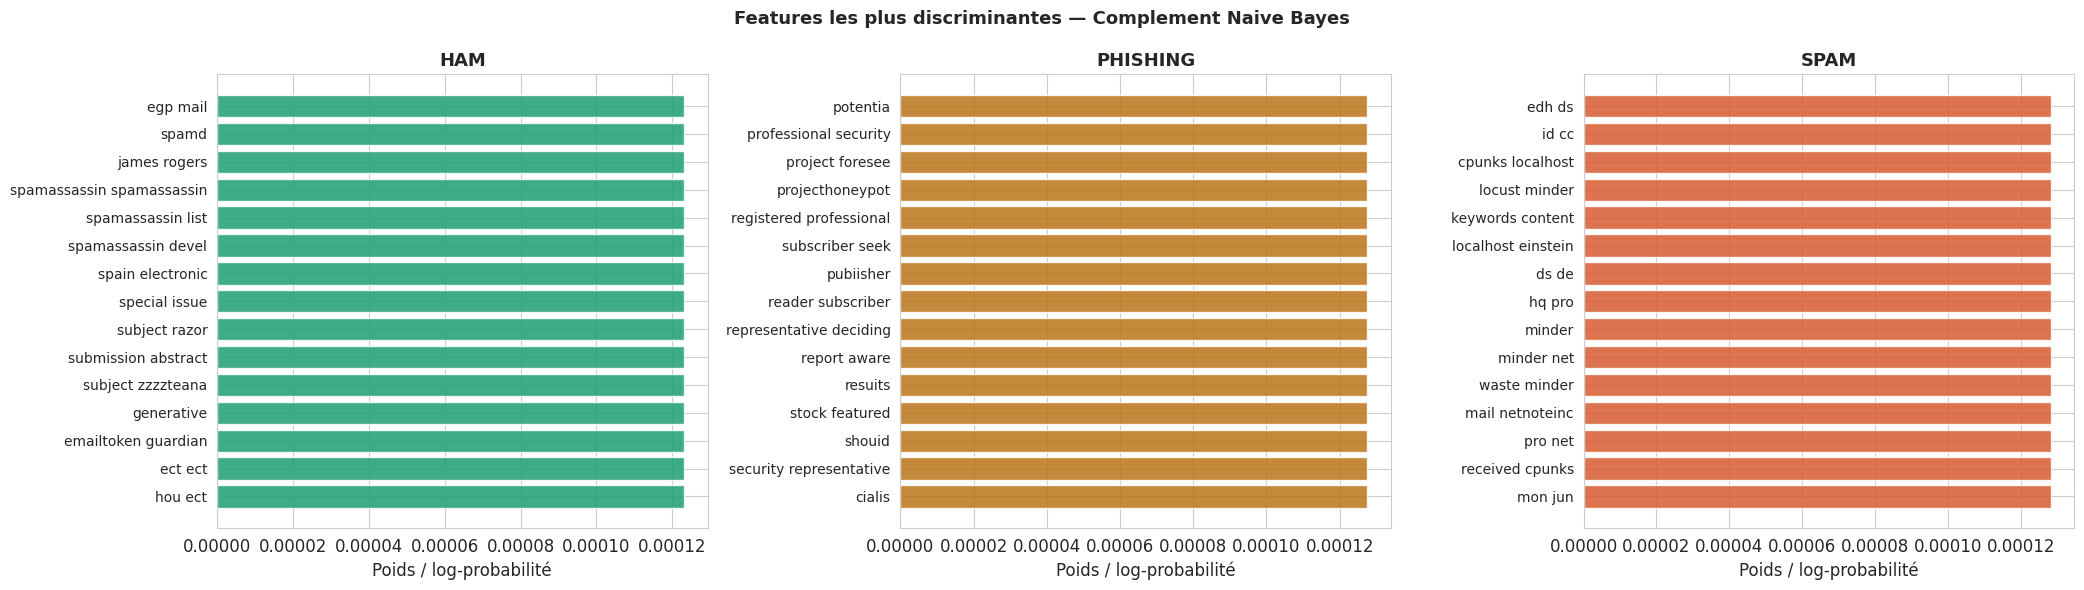

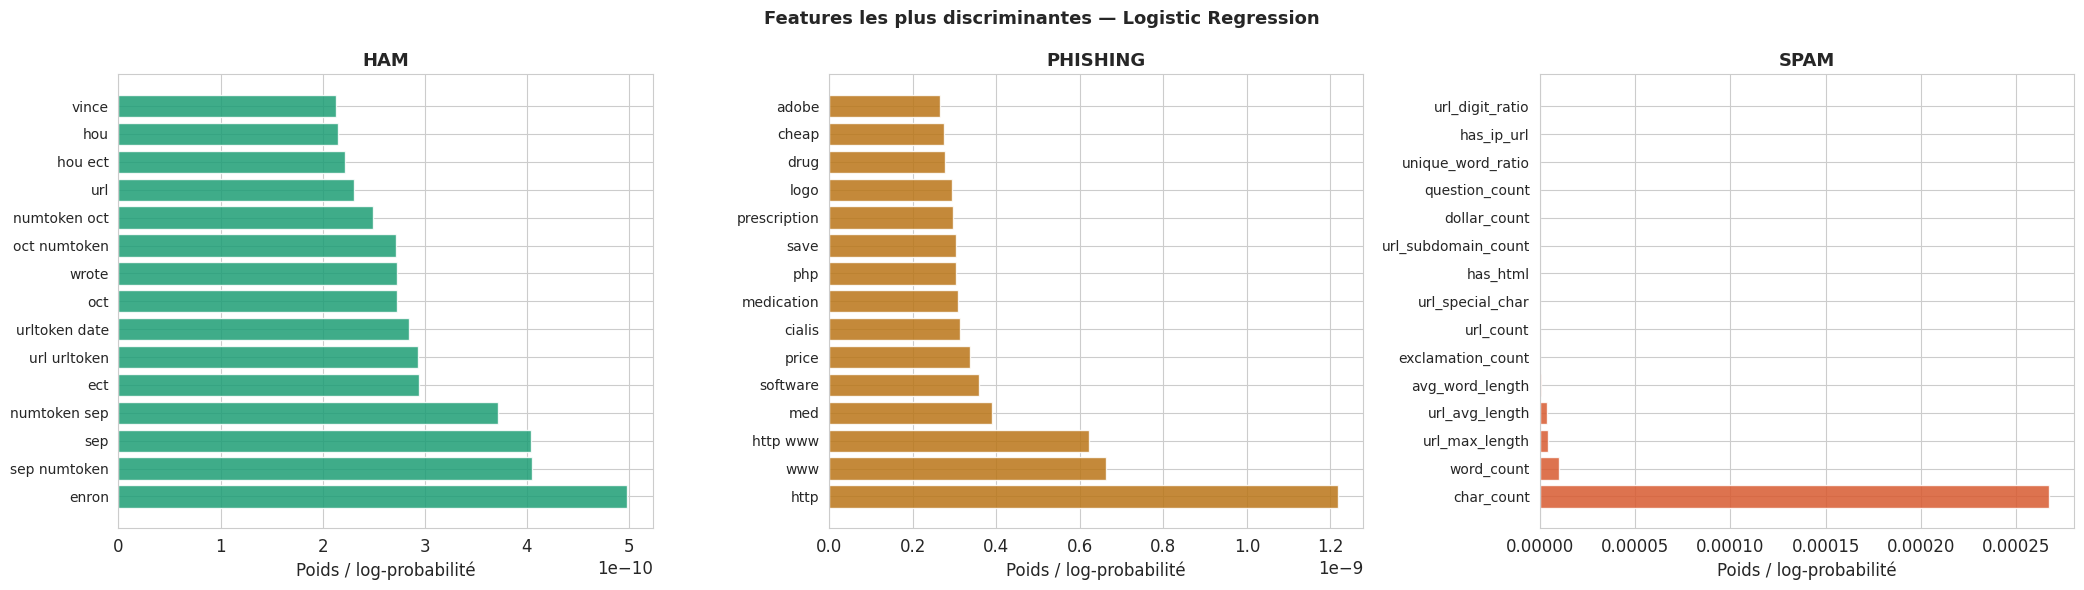

In [13]:
def plot_top_features_per_class(model, model_name, feature_names, class_names, top_n=15):
    """
    Affiche les features les plus importantes pour chaque classe.
    Fonctionne avec LR (coef_) et CNB (feature_log_prob_).
    """
    estimator = model
    # Dérouler CalibratedClassifierCV si nécessaire
    if hasattr(model, 'estimator'):
        estimator = model.estimator
    elif hasattr(model, 'calibrated_classifiers_'):
        estimator = model.calibrated_classifiers_[0].estimator

    if hasattr(estimator, 'coef_'):
        coef = estimator.coef_
    elif hasattr(estimator, 'feature_log_prob_'):
        coef = estimator.feature_log_prob_
    else:
        print(f'{model_name} : pas de coef_ accessible pour l\'interprétabilité.')
        return

    n_classes = len(class_names)
    fig, axes = plt.subplots(1, n_classes, figsize=(7*n_classes, 6))
    if n_classes == 1:
        axes = [axes]

    feature_arr = np.array(feature_names)

    for ax, class_name, class_coef in zip(axes, class_names, coef):
        top_idx    = class_coef.argsort()[-top_n:][::-1]
        bottom_idx = class_coef.argsort()[:top_n]

        top_features = feature_arr[top_idx]
        top_scores   = class_coef[top_idx]

        color = CLASS_COLORS.get(class_name, '#378ADD')
        ax.barh(range(top_n), top_scores[::-1], color=color, alpha=0.85)
        ax.set_yticks(range(top_n))
        ax.set_yticklabels(top_features[::-1], fontsize=10)
        ax.set_title(f'{class_name.upper()}', fontweight='bold', fontsize=13)
        ax.set_xlabel('Poids / log-probabilité')
        ax.invert_yaxis()

    plt.suptitle(f'Features les plus discriminantes — {model_name}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    safe_name = model_name.replace(' ', '_').lower()
    plt.savefig(f'data/03_features_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Interprétabilité pour LR et CNB
for name in ['Complement Naive Bayes', 'Logistic Regression']:
    if name in trained_models:
        plot_top_features_per_class(
            trained_models[name], name, feature_names, CLASS_NAMES, top_n=15
        )

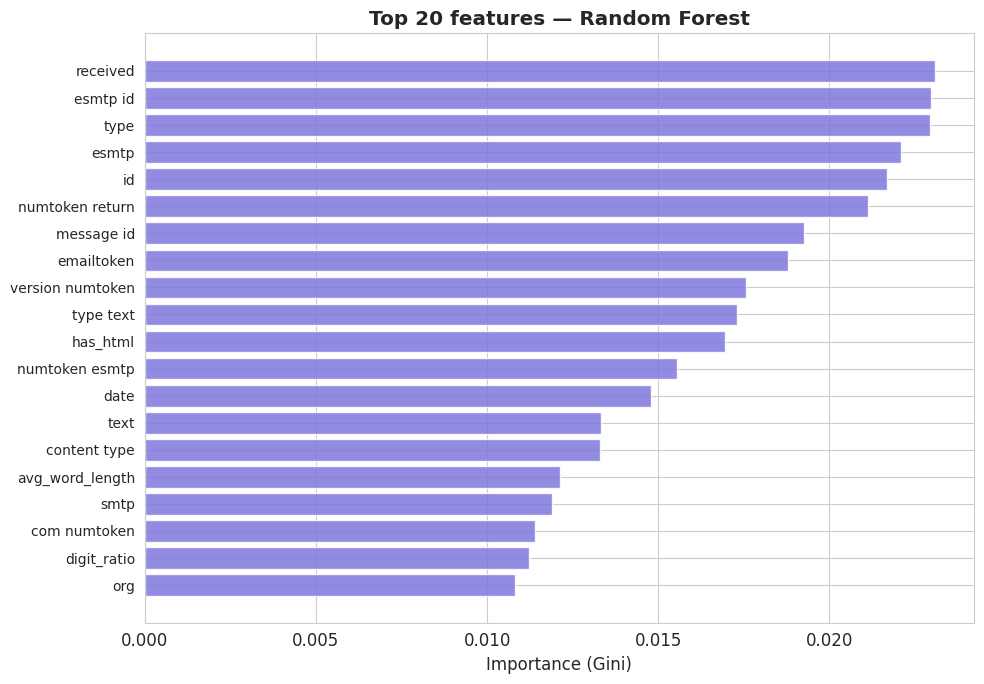

In [14]:
# Importance des features pour Random Forest
rf_model = trained_models.get('Random Forest')
if rf_model is not None and hasattr(rf_model, 'feature_importances_'):
    importances   = rf_model.feature_importances_
    top_n         = 20
    top_idx       = importances.argsort()[-top_n:][::-1]
    top_feat      = np.array(feature_names)[top_idx]
    top_imp       = importances[top_idx]

    plt.figure(figsize=(10, 7))
    plt.barh(range(top_n), top_imp[::-1], color='#7F77DD', alpha=0.85)
    plt.yticks(range(top_n), top_feat[::-1], fontsize=10)
    plt.xlabel('Importance (Gini)')
    plt.title(f'Top {top_n} features — Random Forest', fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/03_features_random_forest.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Évaluation finale sur le Test set

Le test set n'a été touché à **aucun moment** pendant l'entraînement ou la sélection. C'est maintenant qu'on l'utilise, une seule fois, pour estimer les performances réelles.

In [15]:
# Sélection du meilleur modèle basée sur F1-macro (validation set)
best_name = df_results.loc[df_results['f1_macro'].idxmax(), 'model']
best_model = trained_models[best_name]

print(f'Meilleur modèle sélectionné : {best_name}')
print(f'  F1-macro (validation) : {df_results[df_results["model"]==best_name]["f1_macro"].values[0]:.4f}')
print()

# Évaluation sur le test set
y_test_pred = best_model.predict(X_test)

print('=== RÉSULTATS FINAUX SUR LE TEST SET ===')
print(classification_report(
    y_test, y_test_pred,
    target_names=[c.upper() for c in CLASS_NAMES],
    digits=4
))

# Métriques synthétiques
test_f1  = f1_score(y_test, y_test_pred, average='macro')
test_acc = accuracy_score(y_test, y_test_pred)

try:
    y_proba_test = best_model.predict_proba(X_test)
    y_bin_test   = label_binarize(y_test, classes=list(range(N_CLASSES)))
    test_auc = roc_auc_score(y_bin_test, y_proba_test, multi_class='ovr', average='macro')
except Exception:
    test_auc = float('nan')

print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test F1-Macro : {test_f1:.4f}')
print(f'Test AUC-ROC  : {test_auc:.4f}')

Meilleur modèle sélectionné : Random Forest
  F1-macro (validation) : 0.9417

=== RÉSULTATS FINAUX SUR LE TEST SET ===
              precision    recall  f1-score   support

         HAM     0.9973    0.8957    0.9438      2081
    PHISHING     0.8355    0.9952    0.9084      1046
        SPAM     0.9459    1.0000    0.9722       210

    accuracy                         0.9335      3337
   macro avg     0.9262    0.9636    0.9415      3337
weighted avg     0.9434    0.9335    0.9345      3337

Test Accuracy : 0.9335
Test F1-Macro : 0.9415
Test AUC-ROC  : 0.9966


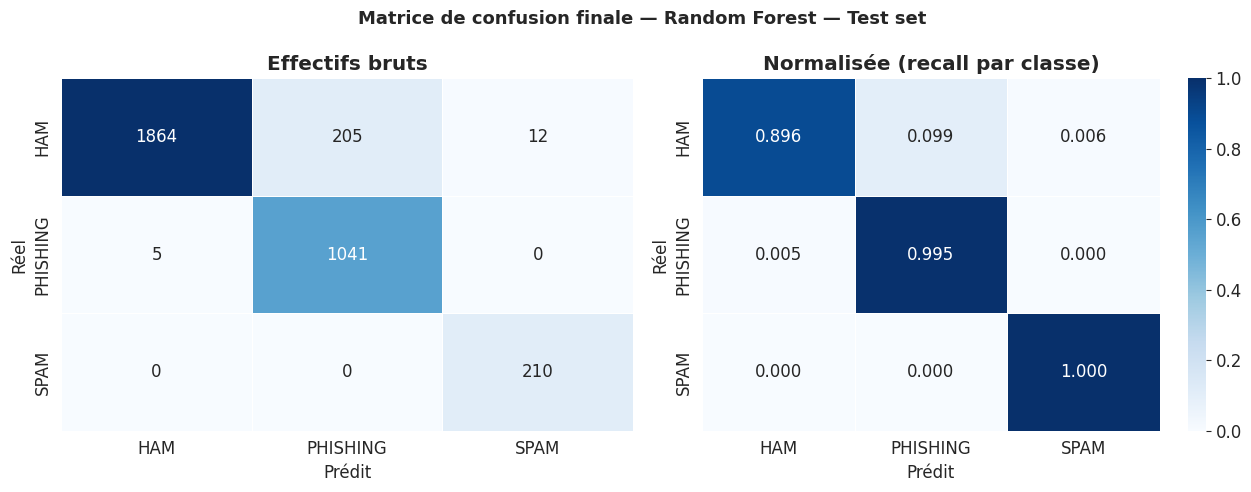

In [16]:
# Matrice de confusion finale
cm_test = confusion_matrix(y_test, y_test_pred)
cm_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Effectifs bruts
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.upper() for c in CLASS_NAMES],
            yticklabels=[c.upper() for c in CLASS_NAMES],
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_title('Effectifs bruts', fontweight='bold')
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')

# Normalisée (recall)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=[c.upper() for c in CLASS_NAMES],
            yticklabels=[c.upper() for c in CLASS_NAMES],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Normalisée (recall par classe)', fontweight='bold')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')

plt.suptitle(f'Matrice de confusion finale — {best_name} — Test set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/03_final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Analyse des erreurs

Comprendre les erreurs est aussi important que mesurer la précision. Les faux positifs ham (emails légitimes bloqués) sont particulièrement coûteux dans un contexte professionnel (§1.4 du cahier de charges).

In [17]:
# Chargement du texte pour l'analyse d'erreurs
df_full = pd.read_csv(DATA_DIR / 'emails_features.csv')

# On reconstitue les indices du test set
# (approximatif si le shuffle n'est pas reproductible — à adapter)
# Idéalement, sauvegarder les indices dans NB 02

print('Analyse des erreurs sur le test set')
print(f'Total emails testés : {len(y_test):,}')
print()

# Erreurs par type
error_analysis = []
for true_idx in range(N_CLASSES):
    for pred_idx in range(N_CLASSES):
        if true_idx != pred_idx:
            count = cm_test[true_idx, pred_idx]
            pct   = count / cm_test[true_idx].sum() * 100
            error_analysis.append({
                'Réel':    CLASS_NAMES[true_idx].upper(),
                'Prédit':  CLASS_NAMES[pred_idx].upper(),
                'Count':   count,
                'Rate (%)': round(pct, 2),
                'Gravité': '⚠ ÉLEVÉE' if CLASS_NAMES[true_idx] == 'ham' else 'Modérée'
            })

df_errors = pd.DataFrame(error_analysis).sort_values('Count', ascending=False)
print(df_errors.to_string(index=False))
print()

# Focus faux positifs ham
if 'ham' in CLASS_NAMES:
    ham_idx  = CLASS_NAMES.index('ham')
    fp_total = cm_test[ham_idx].sum() - cm_test[ham_idx, ham_idx]
    fp_rate  = fp_total / cm_test[ham_idx].sum() * 100
    print(f'Faux positifs HAM (emails légitimes bloqués) : {fp_total} ({fp_rate:.2f}%)')
    if fp_rate < 1:
        print('  → Excellent : moins de 1% des emails légitimes sont bloqués.')
    elif fp_rate < 5:
        print('  → Acceptable mais à surveiller en production.')
    else:
        print('  → Problématique : trop d\'emails légitimes bloqués. Ajuster le seuil de décision.')

Analyse des erreurs sur le test set
Total emails testés : 3,337

    Réel   Prédit  Count  Rate (%)  Gravité
     HAM PHISHING    205      9.85 ⚠ ÉLEVÉE
     HAM     SPAM     12      0.58 ⚠ ÉLEVÉE
PHISHING      HAM      5      0.48  Modérée
PHISHING     SPAM      0      0.00  Modérée
    SPAM      HAM      0      0.00  Modérée
    SPAM PHISHING      0      0.00  Modérée

Faux positifs HAM (emails légitimes bloqués) : 217 (10.43%)
  → Problématique : trop d'emails légitimes bloqués. Ajuster le seuil de décision.


## 9. Sauvegarde du meilleur modèle

In [18]:
# Sauvegarde du meilleur modèle
joblib.dump(best_model, DATA_DIR / 'best_model.pkl')
print(f'Meilleur modèle sauvegardé : data/best_model.pkl')
print(f'  Modèle : {best_name}')

# Sauvegarde du tableau de résultats complet
df_results_export = df_results.drop(columns=[c for c in df_results.columns
                                              if c.startswith('_')])
df_results_export.to_csv(DATA_DIR / '03_results.csv', index=False)

# Sauvegarde des métriques test du meilleur modèle
test_metrics = {
    'model':        best_name,
    'test_accuracy': float(test_acc),
    'test_f1_macro': float(test_f1),
    'test_auc_roc':  float(test_auc),
}
import json
with open(DATA_DIR / 'best_model_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)

print()
print('Fichiers produits pour NB 04 & 05 :')
for fname in ['best_model.pkl', '03_results.csv', 'best_model_metrics.json']:
    p = DATA_DIR / fname
    status = '✓' if p.exists() else '✗'
    print(f'  {status} {fname}')

Meilleur modèle sauvegardé : data/best_model.pkl
  Modèle : Random Forest

Fichiers produits pour NB 04 & 05 :
  ✓ best_model.pkl
  ✓ 03_results.csv
  ✓ best_model_metrics.json


## 10. Résumé & décisions

### Tableau de bord final

In [19]:
print('=' * 60)
print('RÉSUMÉ — Notebook 03 : Modèles ML Classiques')
print('=' * 60)

display_cols = ['model', 'accuracy', 'f1_macro', 'auc_roc', 'infer_ms']
df_show = df_results[display_cols].round(4).sort_values('f1_macro', ascending=False)
df_show.columns = ['Modèle', 'Accuracy', 'F1-Macro', 'AUC-ROC', 'Latence (ms)']

print('\nClassement par F1-Macro (validation) :')
print(df_show.to_string(index=False))

print(f'\nMeilleur modèle : {best_name}')
print(f'  Test Accuracy  : {test_acc:.4f}')
print(f'  Test F1-Macro  : {test_f1:.4f}')
print(f'  Test AUC-ROC   : {test_auc:.4f}')

print()
print('Décisions pour la suite :')
print('  - NB 04 : fine-tuner DistilBERT sur emails_features.csv')
print('    → Comparer ses performances avec le meilleur modèle ML classique')
print('  - NB 05 : intégrer best_model.pkl dans le pipeline hybride')
print('    → Combiner avec l\'analyse des headers et la réputation des domaines')

print()
print('Risques adressés dans ce notebook (cf. cahier de charges) :')
print('  ✓ §1.3 Déséquilibre : class_weight + SMOTE (NB 02)')
print('  ✓ §1.4 Faux positifs : mesurés et commentés')
print('  ✓ §1.5 Latence : mesurée pour chaque modèle')
print('  ✓ §3.4 Métriques multidimensionnelles : accuracy, F1, AUC, CM')
print('  ✓ §4.1 Surapprentissage : validation croisée 5-fold')

RÉSUMÉ — Notebook 03 : Modèles ML Classiques

Classement par F1-Macro (validation) :
                Modèle  Accuracy  F1-Macro  AUC-ROC  Latence (ms)
         Random Forest    0.9337    0.9417   0.9962        0.1460
             LinearSVC    0.8756    0.8649   0.9673        0.0187
Complement Naive Bayes    0.3197    0.3278   0.7598        0.0028
   Logistic Regression    0.0627    0.0394   0.6391        0.0010

Meilleur modèle : Random Forest
  Test Accuracy  : 0.9335
  Test F1-Macro  : 0.9415
  Test AUC-ROC   : 0.9966

Décisions pour la suite :
  - NB 04 : fine-tuner DistilBERT sur emails_features.csv
    → Comparer ses performances avec le meilleur modèle ML classique
  - NB 05 : intégrer best_model.pkl dans le pipeline hybride
    → Combiner avec l'analyse des headers et la réputation des domaines

Risques adressés dans ce notebook (cf. cahier de charges) :
  ✓ §1.3 Déséquilibre : class_weight + SMOTE (NB 02)
  ✓ §1.4 Faux positifs : mesurés et commentés
  ✓ §1.5 Latence : mesurée 